# Code for processing the results
Let us have a look at the handcrafted designs and compare the FEM code results with CST. The FEM code uses rectangular vector edge elements [1] to solve the Helmholtz equation in the form of eigenvalue problem 

$ \begin{bmatrix}
A_{tt} & 0 \\
0 & 0 
\end{bmatrix} 
\begin{Bmatrix}
e_{t} \\
e_z
\end{Bmatrix}  = -k_z^2
\begin{bmatrix}
B_{tt} & B_{tz} \\
B_{zy} & B_{zz} 
\end{bmatrix} 
\begin{Bmatrix}
e_{t} \\
e_z
\end{Bmatrix}$

For more details about the operators see [1] pg.290.

In the FEM code a linear interpolation of effective dielectric permittivity is assumed

$\epsilon_\mathrm{r} (x) = \epsilon_\mathrm{r, bck} + x(\epsilon_\mathrm{r, met} - \epsilon_\mathrm{r, bck})$,

where $\epsilon_\mathrm{r, met} = 10000^2$ and $\epsilon_\mathrm{r, bck} = 1.0003^2$. At the start we compare the mode cutoff frequencies calculated from the propagation wavelength as

$f_c = \frac{c\sqrt{1-(\frac{\lambda}{\lambda_\mathrm{g}})^2}}{\lambda}$, where $c$ stands for the speed of light in vacuum, $\lambda_\mathrm{g}$ is the propagation wavelength and is related to the eigenvalues as $\kappa = -k_z^2$, where $\kappa$ is the eigenvalue and $\lambda$ is the wavelength of the wave traveling in an unbounded medium whose electrical parameters $\epsilon$ and $\mu$ are the same as those of the medium inside the waveguide [2].

## References

[1] Jianming Jin. 2014. The Finite Element Method in Electromagnetics (3rd. ed.). Wiley-IEEE Press.

[2] Constantine A. Balanis. 2012. Advanced Engineering Electromagnetics. Wiley.

## Comparison of the rectangular waveguide
In this document we will compare the results from the mode solver of CST and the FEM code using cutoff frequencies. Furthermore, this document provides the depiction of the absolute value of electric field intensity calculated as $|\Re\{E\}|$.
<table>
  <tr>
    <td>
      <figure style="text-align:center">
        <img src="./Rectangular Waveguide/E_mode1_CST_FDTD.png" width="800"/>
        <figcaption>CST Mode 1</figcaption>
      </figure>
    </td>
    <td>
      <figure style="text-align:center">
        <img src="./Rectangular Waveguide/|E|_mode1_FEM.png" width="800"/>
        <figcaption>FEM Mode 1</figcaption>
      </figure>
    </td>
  </tr>
  <tr>
    <td>
      <figure style="text-align:center">
        <img src="./Rectangular Waveguide/E_mode2_CST_FDTD.png" width="800"/>
        <figcaption>CST Mode 2</figcaption>
      </figure>
    </td>
    <td>
      <figure style="text-align:center">
        <img src="./Rectangular Waveguide/|E|_mode2_FEM.png" width="800"/>
        <figcaption>FEM Mode 2</figcaption>
      </figure>
    </td>
  </tr>
  <tr>
    <td>
      <figure style="text-align:center">
        <img src="./Rectangular Waveguide/E_mode3_CST_FDTD.png" width="800"/>
        <figcaption>CST Mode 3</figcaption>
      </figure>
    </td>
    <td>
      <figure style="text-align:center">
        <img src="./Rectangular Waveguide/|E|_mode3_FEM.png" width="800"/>
        <figcaption>FEM Mode 3</figcaption>
      </figure>
    </td>
  </tr>
</table>



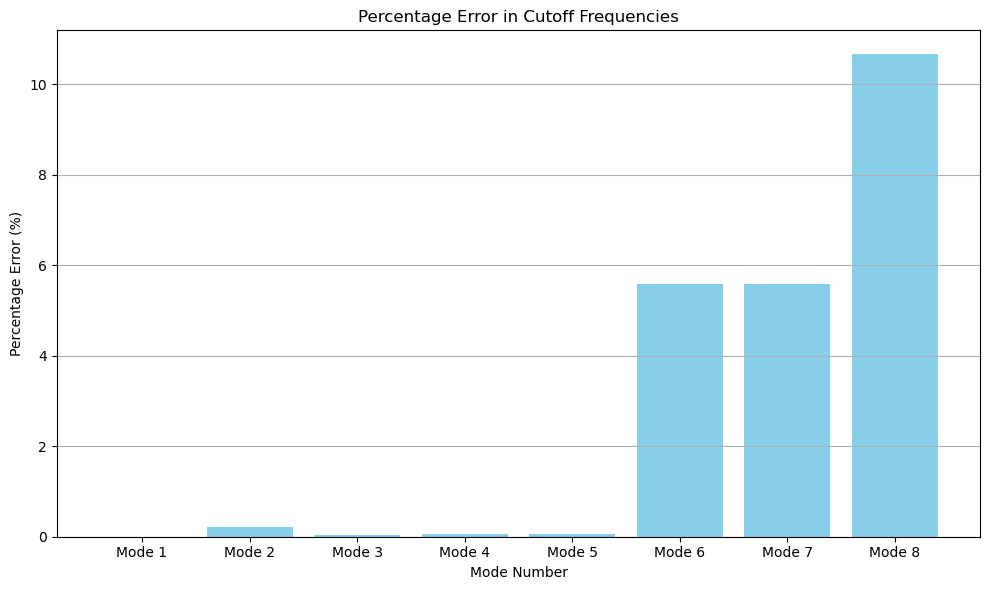

Bandwidth ratio (f2/f1): 2.00


In [8]:
# Rectangular waveguide cutoff comparison
import numpy as np
import matplotlib.pyplot as plt
cutoff_freqs_FEM = np.genfromtxt('./Rectangular Waveguide/cutoff_frequencies_FEM.csv', delimiter='\n', dtype=float)
cutoff_freqs_CST = np.genfromtxt('./Rectangular Waveguide/cutoff_frequencies_CST.csv', delimiter='\n', dtype=float)
cutoff_freqs_FEM = cutoff_freqs_FEM / 1e9  # Convert to GHz
k = len(cutoff_freqs_CST)
errors = np.abs(cutoff_freqs_FEM[0:k] - cutoff_freqs_CST) / cutoff_freqs_CST * 100  # Percentage error
# display the errors nicely
plt.figure(figsize=(10, 6))
plt.bar(range(1, k + 1), errors, color='skyblue')
plt.xticks(range(1, k + 1), [f'Mode {i}' for i in range(1, k + 1)])
plt.xlabel('Mode Number')
plt.ylabel('Percentage Error (%)')
plt.title('Percentage Error in Cutoff Frequencies')
plt.grid(axis='y')
plt.tight_layout()
plt.show()
# bandwidth ratio
bandwidth_ratio =  cutoff_freqs_FEM[1] / cutoff_freqs_FEM[0]
print(f"Bandwidth ratio (f2/f1): {bandwidth_ratio:.2f}")


## Comparison of the h waveguide

<table>
  <tr>
    <td>
      <figure style="text-align:center">
        <img src="./H Waveguide - handcrafted/E_mode1_CST_FDTD.png" width="800"/>
        <figcaption>CST Mode 1</figcaption>
      </figure>
    </td>
    <td>
      <figure style="text-align:center">
        <img src="./H Waveguide - handcrafted/|E|_mode1_FEM.png" width="800"/>
        <figcaption>FEM Mode 1</figcaption>
      </figure>
    </td>
  </tr>
  <tr>
    <td>
      <figure style="text-align:center">
        <img src="./H Waveguide - handcrafted/E_mode2_CST_FDTD.png" width="800"/>
        <figcaption>CST Mode 2</figcaption>
      </figure>
    </td>
    <td>
      <figure style="text-align:center">
        <img src="./H Waveguide - handcrafted/|E|_mode2_FEM.png" width="800"/>
        <figcaption>FEM Mode 2</figcaption>
      </figure>
    </td>
  </tr>
  <tr>
    <td>
      <figure style="text-align:center">
        <img src="./H Waveguide - handcrafted/E_mode3_CST_FDTD.png" width="800"/>
        <figcaption>CST Mode 3</figcaption>
      </figure>
    </td>
    <td>
      <figure style="text-align:center">
        <img src="./H Waveguide - handcrafted/|E|_mode3_FEM.png" width="800"/>
        <figcaption>FEM Mode 3</figcaption>
      </figure>
    </td>
  </tr>
</table>


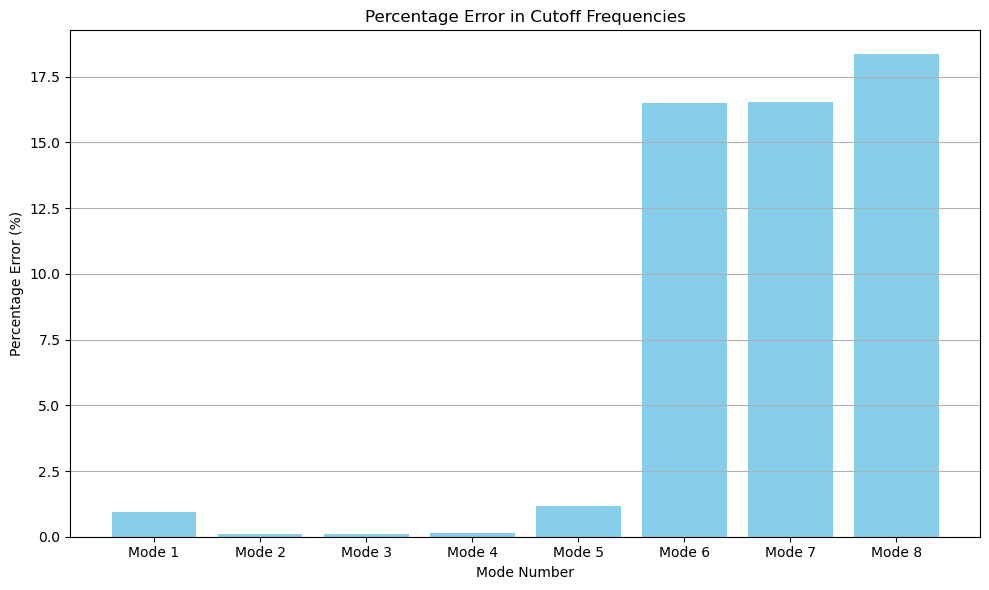

Bandwidth ratio (f2/f1): 3.36


In [10]:
# H waveguide cutoff comparison
import numpy as np
import matplotlib.pyplot as plt
cutoff_freqs_FEM = np.genfromtxt('./H Waveguide - handcrafted/cutoff_frequencies_FEM.csv', delimiter='\n', dtype=float)
cutoff_freqs_CST = np.genfromtxt('./H Waveguide - handcrafted/cutoff_frequencies_CST.csv', delimiter='\n', dtype=float)
cutoff_freqs_FEM = cutoff_freqs_FEM / 1e9  # Convert to GHz
k = len(cutoff_freqs_CST)
errors = np.abs(cutoff_freqs_FEM[0:k] - cutoff_freqs_CST) / cutoff_freqs_CST * 100  # Percentage error
# display the errors nicely
plt.figure(figsize=(10, 6))
plt.bar(range(1, k + 1), errors, color='skyblue')
plt.xticks(range(1, k + 1), [f'Mode {i}' for i in range(1, k + 1)])
plt.xlabel('Mode Number')
plt.ylabel('Percentage Error (%)')
plt.title('Percentage Error in Cutoff Frequencies')
plt.grid(axis='y')
plt.tight_layout()
plt.show()
# bandwidth ratio
bandwidth_ratio =  cutoff_freqs_FEM[1] / cutoff_freqs_FEM[0]
print(f"Bandwidth ratio (f2/f1): {bandwidth_ratio:.2f}")